# Lecture 8b — The factor zoo, for real

**AI-powered Investment and Risk Management (25882) · Vitali Alexeev · UTS Business School**

Lecture 8a worked on data we invented. This notebook works on the actual published
cross-sectional return predictors — several hundred of them — and asks the question
the lecture opened with:

> Any five of these will look excellent in-sample. **Which ones actually price assets,
> and how would you know?**

### What we do

1. Pull the zoo and look at the distribution of $t$-statistics across every signal.
2. Watch what a multiple-testing hurdle does to the survivor count — and, because we
   have ground truth in the simulated version, measure how many survivors are real.
3. Select the best performers in-sample and look at what they do afterwards.
   Selection bias stops being an abstraction.
4. Build a stochastic discount factor from the whole zoo, and sweep the shrinkage
   parameter. This is Kozak, Nagel and Santosh (2020) at teaching scale.

### Two data paths

The notebook prefers the real Open Source Asset Pricing data (Chen & Zimmermann,
2022). If that download is unavailable — it is served from Google Drive and is
routinely blocked on university networks — it falls back to a **simulated zoo where
we know which signals are genuine.**

The fallback is not a consolation prize. Real data cannot tell you which published
anomalies are real, which is the whole question. The simulation can. Where the two
paths differ, the notebook says so explicitly.

*Runtime: 3–6 minutes on the simulated zoo; longer if the real download runs.*

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go

import airm8
from airm8 import *

pd.set_option("display.precision", 3)
RNG = lambda seed: np.random.default_rng(seed)

In [2]:
# Prefer the real zoo; fall back to the simulated one if it is unreachable.
#
# Note the narrow except clause. Catching bare `Exception` here would mean a
# typo in the loader silently produced simulated data while the notebook
# reported it as real -- the exact failure mode this lecture is about. These
# four cover every genuine "data unavailable" route; anything else should
# raise and be fixed.
TRUTH = None
try:
    zoo = load_open_source_zoo()
    SOURCE = "Open Source Asset Pricing (Chen & Zimmermann)"
except (FileNotFoundError, ImportError, OSError, ValueError) as err:
    print(f"Real data unavailable -- {type(err).__name__}: {err}\n")
    print("Falling back to the simulated zoo.\n")
    zoo, TRUTH = make_synthetic_zoo(RNG(7))
    SOURCE = "Simulated zoo (ground truth available)"

# Keep only signals with a complete history in this window, and keep TRUTH
# aligned with whatever survives. Dropping columns without re-indexing TRUTH
# would misalign every `is_true` flag downstream, silently.
keep = zoo.columns[zoo.notna().all()]
zoo = zoo[keep]
if TRUTH is not None:
    TRUTH = TRUTH.reindex(keep)

print(f"Source : {SOURCE}")
print(f"Signals: {zoo.shape[1]}")
print(f"Period : {zoo.index.min():%Y-%m} to {zoo.index.max():%Y-%m} "
      f"({len(zoo)} months)")
if TRUTH is not None:
    print(f"Truly non-zero: {int(TRUTH.sum())} of {len(TRUTH)} "
          f"({TRUTH.mean():.0%})")
    assert len(TRUTH) == zoo.shape[1], "TRUTH and zoo have drifted apart"

Source : Open Source Asset Pricing (Chen & Zimmermann)
Signals: 158
Period : 1975-01 to 2024-12 (600 months)


### What are these signals, actually?

The column names are acronyms. Before doing anything with them it is worth knowing
what they are — several turn out to be variations on the same idea, which is itself
part of the point of this lecture.

The table below is built from Chen and Zimmermann's own documentation, so it stays
correct if the data is updated.

In [3]:
catalogue = describe_signals(zoo.columns).sort_values(["Category", "Year"])
catalogue["Year"] = catalogue["Year"].fillna(0).astype(int)

print(f"{len(catalogue)} signals across "
      f"{catalogue.Category.nunique()} economic categories:\n")
print(catalogue.Category.value_counts().to_string())

158 signals across 30 economic categories:

Category
other                     23
valuation                 15
external financing        11
momentum                  11
investment alt             9
investment                 8
liquidity                  8
profitability              7
long term reversal         6
risk                       6
sales growth               6
R&D                        4
accruals                   4
asset composition          4
leverage                   4
short sale constraints     4
volatility                 4
volume                     4
earnings growth            3
investment growth          3
payout indicator           3
composite accounting       2
lead lag                   2
cash flow risk             1
default risk               1
earnings event             1
info proxy                 1
profitability alt          1
short-term reversal        1
size                       1


In [4]:
# The full reference table. Sort or filter it as you like -- for example
#     catalogue.loc[catalogue.Category == "momentum"]
#     catalogue.loc[catalogue.Description.str.contains("accrual", case=False)]
pd.set_option("display.max_rows", 250, "display.max_colwidth", 60)
catalogue

,Description,Authors,Year,Journal,Category
Acronym,,,,,
AdExp,Advertising Expense,"Chan, Lakonishok and Sougiannis",2001,JF,R&D
RD,R&D over market cap,"Chan, Lakonishok and Sougiannis",2001,JF,R&D
SurpriseRD,Unexpected R&D increase,"Eberhart, Maxwell and Siddique",2004,JF,R&D
OrgCap,Organizational capital,Eisfeldt and Papanikolaou,2013,JF,R&D
Accruals,Accruals,Sloan,1996,AR,accruals
AbnormalAccruals,Abnormal Accruals,Xie,2001,AR,accruals
OrderBacklogChg,Change in order backlog,Baik and Ahn,2007,Other,accruals
PctAcc,Percent Operating Accruals,"Hafzalla, Lundholm, Van Winkle",2011,AR,accruals
NOA,Net Operating Assets,Hirshleifer et al.,2004,JAE,asset composition


Each column is the monthly return on a **long–short portfolio** built from one
signal: long the assets the signal likes, short the ones it does not. If a signal
carries no information, that portfolio has a population mean of exactly zero.

---
## 1. What does the zoo look like?

Start with the summary statistic every anomaly paper reports: the $t$-statistic on
the mean long–short return.

In [5]:
corr = zoo.corr().values[np.triu_indices(zoo.shape[1], 1)]
print(f"Mean pairwise correlation between signals: {corr.mean():.3f}")
print(f"Share of pairs above 0.5 in absolute value: "
      f"{(np.abs(corr) > 0.5).mean():.1%}")

Mean pairwise correlation between signals: 0.048
Share of pairs above 0.5 in absolute value: 10.0%


That number is worth pausing on. Long-short anomaly portfolios are **very nearly
uncorrelated with each other**. Each one is long and short within the same market, so
the market component largely cancels and what remains is close to signal-specific.

Hold onto it: it is the reason Part 4's unpenalised portfolio produces a Sharpe ratio
that cannot possibly be real.

In [6]:
stats = signal_stats(zoo)
if TRUTH is not None:
    stats["is_true"] = TRUTH.reindex(stats.index).values

print(stats[["sharpe", "tstat"]].describe().round(2).to_string())

       sharpe   tstat
count  158.00  158.00
mean     0.52    3.67
std      0.35    2.50
min     -0.24   -1.72
25%      0.29    2.06
50%      0.45    3.17
75%      0.71    5.02
max      2.34   16.53


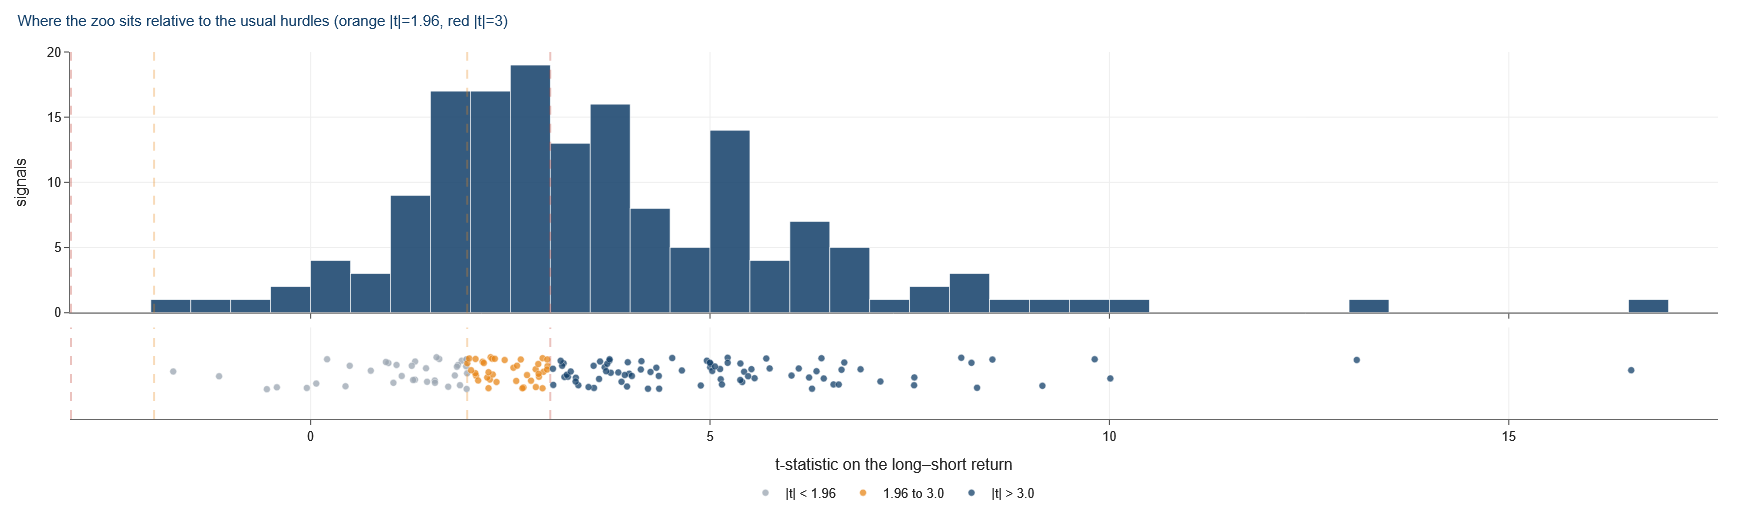

In [7]:
# The histogram carries the shape; the strip beneath carries the identity, so
# every signal can be named on hover. On the simulated zoo the points are
# coloured by whether they are genuinely non-zero.
plot_signal_distribution(
    stats, truth=TRUTH,
    title="Where the zoo sits relative to the usual hurdles "
          "(orange |t|=1.96, red |t|=3)")

Hover the points. On the **simulated** zoo they are coloured by the truth we built
in, so you can see directly how far into the tail a population mean of zero can
reach. On the **real** zoo there is no truth to colour by — which is the whole
difficulty — so they are coloured by which hurdle they clear.

In [8]:
rows = []
for thr in [1.64, 1.96, 2.57, 3.00]:
    passed = stats.tstat.abs() > thr
    row = dict(hurdle=f"|t| > {thr:.2f}", n_passing=int(passed.sum()),
               share=f"{passed.mean():.0%}")
    if TRUTH is not None:
        real = int((passed & stats.is_true).sum())
        row.update(n_genuine=real,
                   precision=f"{real / max(passed.sum(), 1):.2f}",
                   recall=f"{real / int(stats.is_true.sum()):.2f}")
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

    hurdle  n_passing share
|t| > 1.64        134   85%
|t| > 1.96        122   77%
|t| > 2.57        102   65%
|t| > 3.00         84   53%


**On the real zoo**, a striking share of signals clear the conventional hurdle — and
raising it to $|t| > 3$ still leaves about half standing. That looks like a literature
in excellent health.

Be careful. These are signals that were *published*, and then *replicated* by Chen and
Zimmermann. Two filters have already run before the data reached you. The hypotheses
that failed at either stage are not in this file, so we are looking at survivors and
counting how many survived. Part 2 takes that problem seriously.

**On the simulated zoo**, the table also carries precision and recall, because there
we know which signals are genuine. Read them together — it is the same trade-off you
met in Lecture 8a, now applied to hypotheses rather than coefficients. At
$|t| > 1.96$ a substantial share of survivors are chasing noise; at $|t| > 3$ almost
everything surviving is real, but most of the genuine signals have been discarded
along with the noise.

There is no hurdle that delivers both, because no threshold cleanly separates two
overlapping distributions.

<details>
<summary><b>The maths: why the hurdle has to rise with the number of tests</b> (click to expand)</summary>

Test $m$ independent hypotheses at level $\alpha$, all of them null. The
probability of at least one false rejection is

$$1 - (1-\alpha)^m \xrightarrow[m \text{ large}]{} 1.$$

At $\alpha = 0.05$ and $m = 300$, you expect $15$ spurious discoveries and are
essentially certain of at least one. The **Bonferroni** correction tests each at
$\alpha/m$, which for $m=300$ means $|t| \approx 3.9$ — brutal, and it assumes
independence, which factor returns badly violate.

Harvey, Liu and Zhu instead control the **false discovery rate**, the expected
share of rejections that are false, which is both less conservative and better
matched to what a researcher actually wants to know. Their recommended hurdle of
roughly $|t| > 3.0$ comes from that calculation.

</details>

---
## 2. The zoo you can download is not the zoo that was tested

Everything above treats the signals as if they were a random sample of hypotheses.
They are not. A signal reaches publication only if it looked good in the sample
available when someone studied it.

We can simulate exactly that. Below, a signal is "published" only if it cleared
$|t| > 2$ in its own first 20 years of data — and we then look at the resulting
library.

In [9]:
# This runs whichever zoo you loaded above. It builds its own simulation from
# scratch, because the point is a mechanism -- what publication filtering does
# to a library -- and no real dataset can show it. The real zoo contains only
# the survivors; the counterfactual is unobservable outside a simulation.
full, full_truth = make_synthetic_zoo(RNG(7))
pub, pub_truth = make_synthetic_zoo(RNG(7), publication_t=2.0)

print(f"Hypotheses tested : {full.shape[1]:3d}  "
      f"({full_truth.mean():.0%} genuine)")
print(f"Signals published : {pub.shape[1]:3d}  "
      f"({pub_truth.mean():.0%} genuine)")
print(f"\nMean |t| among all tested  : "
      f"{signal_stats(full).tstat.abs().mean():.2f}")
print(f"Mean |t| among published   : "
      f"{signal_stats(pub).tstat.abs().mean():.2f}")
print(f"\nThe filter discarded {full.shape[1] - pub.shape[1]} of "
      f"{full.shape[1]} hypotheses and raised the genuine share from "
      f"{full_truth.mean():.0%} to {pub_truth.mean():.0%}.")

Hypotheses tested : 200  (30% genuine)
Signals published :  11  (73% genuine)

Mean |t| among all tested  : 1.06
Mean |t| among published   : 2.78

The filter discarded 189 of 200 hypotheses and raised the genuine share from 30% to 73%.


Two things happen at once, and they pull in opposite directions.

The published library **is** more genuine than the set of hypotheses tested — the
filter works. That is the Jensen, Kelly and Pedersen (2023) observation: most
published factors do replicate, and the literature is not in crisis.

But the published $t$-statistics are drawn from a **truncated** distribution. They
are conditioned on having been large enough to publish, so they overstate the
underlying effect. That is the McLean and Pontiff (2016) mechanism: the number in
the paper is an upper bound on what you will earn.

Both statements are true simultaneously. Most of the disagreement in Section 2 of
the lecture is about which one to emphasise.

Note why this had to be a simulation even though you may have the real zoo loaded.
The published library is observable; **the hypotheses that were tested and discarded
are not.** No amount of real data recovers the denominator, which is precisely what
makes the multiple-testing correction so contested.

---
## 3. Selection bias, made visible

Forget hypothesis testing. Behave like a practitioner: split the sample in half,
pick the best signals using the first half, and hold them in the second.

In [10]:
half = len(zoo) // 2
train, test = zoo.iloc[:half], zoo.iloc[half:]

s_train = signal_stats(train).sharpe
s_test = signal_stats(test).sharpe

rows = []
for k in [1, 5, 10, 25, 50]:
    picks = s_train.nlargest(k).index
    rows.append(dict(n_picked=k,
                     in_sample=s_train[picks].mean(),
                     out_of_sample=s_test[picks].mean(),
                     shrinkage=1 - s_test[picks].mean() / s_train[picks].mean()))

sel = pd.DataFrame(rows)
sel["shrinkage"] = sel.shrinkage.map(lambda v: f"{v:.0%}")
print("Average annualised Sharpe of the top-k signals, chosen in-sample:\n")
print(sel.to_string(index=False))
print(f"\nFor reference, all {zoo.shape[1]} signals equally weighted:")
print(f"   first half {s_train.mean():.3f}   second half {s_test.mean():.3f}")

Average annualised Sharpe of the top-k signals, chosen in-sample:

 n_picked  in_sample  out_of_sample shrinkage
        1      3.413          1.542       55%
        5      2.632          0.878       67%
       10      2.239          0.806       64%
       25      1.732          0.630       64%
       50      1.379          0.529       62%

For reference, all 158 signals equally weighted:
   first half 0.767   second half 0.351


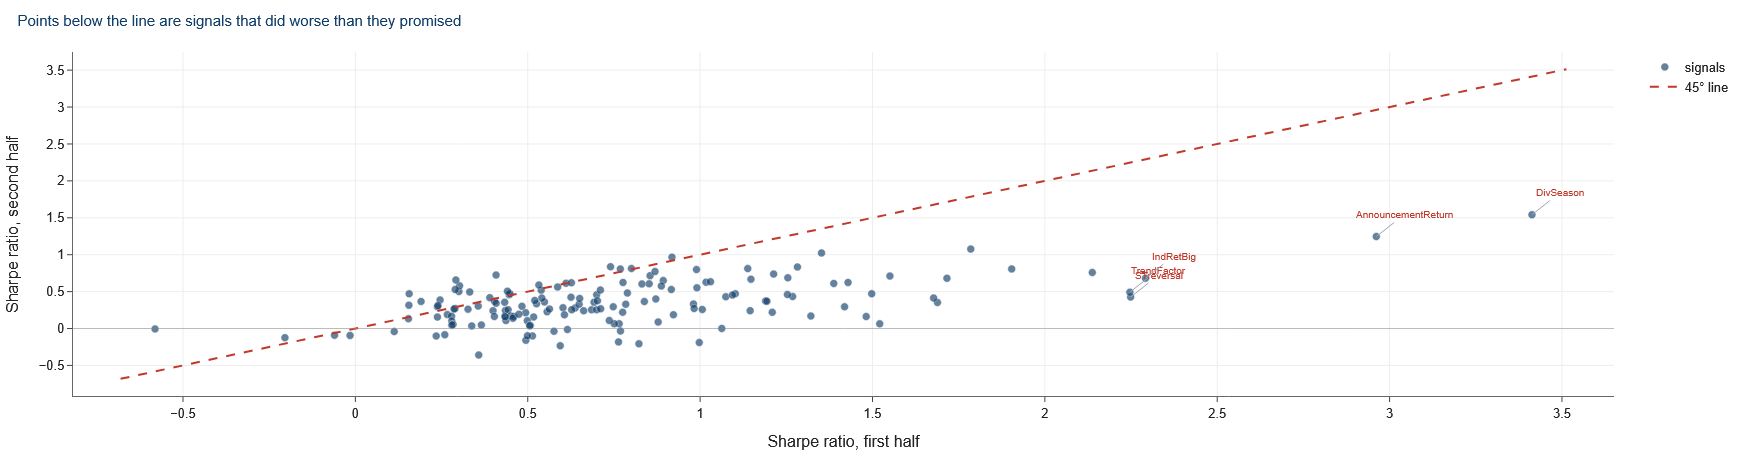

In [11]:
# Attach the full name of each signal so the points can be identified rather
# than guessed at from the acronym.
doc = describe_signals(s_train.index)
label = doc.Description.fillna(pd.Series(s_train.index, index=s_train.index))

scatter = pd.DataFrame({
    "in_sample": s_train, "out_of_sample": s_test,
    "name": label, "authors": doc.Authors.fillna(""),
    "year": doc.Year.fillna(0).astype(int), "category": doc.Category.fillna(""),
})
scatter["decay"] = scatter.in_sample - scatter.out_of_sample

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=scatter.in_sample, y=scatter.out_of_sample, mode="markers",
    marker=dict(color=NAVY, size=8, opacity=0.65,
                line=dict(width=0.5, color="white")),
    name="signals",
    customdata=scatter[["name", "authors", "year", "category", "decay"]].values,
    hovertemplate=("<b>%{text}</b><br>%{customdata[0]}<br>"
                   "%{customdata[1]} (%{customdata[2]}) · %{customdata[3]}"
                   "<br><br>first half   %{x:.2f}"
                   "<br>second half  %{y:.2f}"
                   "<br>gave up      %{customdata[4]:.2f}<extra></extra>"),
    text=scatter.index))

lim = [min(s_train.min(), s_test.min()) - 0.1,
       max(s_train.max(), s_test.max()) + 0.1]
fig.add_trace(go.Scatter(x=lim, y=lim, mode="lines", name="45° line",
                         line=dict(color=RED, width=2, dash="dash")))
fig.add_hline(y=0, line=dict(color="#BBBBBB", width=1))

# Name the five biggest disappointments directly on the chart.
for nm, r in scatter.nlargest(5, "decay").iterrows():
    fig.add_annotation(x=r.in_sample, y=r.out_of_sample, text=nm,
                       showarrow=True, arrowhead=0, arrowwidth=1,
                       arrowcolor=GREY, ax=28, ay=-22,
                       font=dict(size=10, color=RED))

fig.update_xaxes(title="Sharpe ratio, first half")
fig.update_yaxes(title="Sharpe ratio, second half")
airm_layout(fig, "Points below the line are signals that did worse than "
                 "they promised")

Hover any point for the signal's full name, the paper that documented it, and how
much of its first-half Sharpe ratio it gave up. The five biggest disappointments are
labelled directly.

The scatter is the whole of Section 2 in one picture. The cloud sits **below** the
45° line at the right-hand end: the signals that looked best in the first half
systematically disappointed in the second.

Note the mechanism carefully, because it is easy to mis-state. Each signal's
out-of-sample Sharpe is an **unbiased** estimate of its true Sharpe. What is biased
is the *selection*: choosing the maximum of many noisy estimates picks the ones whose
noise happened to be favourable, and noise does not repeat.

This is why a backtest of a strategy you chose after looking at the data tells you
almost nothing — the Lecture 5 lesson, arriving from a different direction.

---
## 4. Building a stochastic discount factor from the whole zoo

Selecting is one response to the zoo. Kozak, Nagel and Santosh argue for a different
one: **keep everything, and shrink.**

Recall from the lecture that the SDF is a portfolio, with weights $w = \Sigma^{-1}\mu$.
With a few hundred correlated signals and a few hundred months, $\Sigma^{-1}$ is
precisely where estimation error does its worst damage.

<details>
<summary><b>The maths: recovering SDF weights by regressing a constant on returns</b> (click to expand)</summary>

The mean-variance efficient portfolio maximises the Sharpe ratio, and equivalently
minimises the pricing error of the implied discount factor:

$$\min_w \; \mathbb{E}\left[(1 - R'w)^2\right].$$

That is a linear regression of a column of **ones** on the returns, with no
intercept. Its solution is $w = \mathbb{E}[RR']^{-1}\mathbb{E}[R]$, the
second-moment version of $\Sigma^{-1}\mu$.

Writing it this way is convenient: penalising the SDF is now just penalising a
regression, so `Ridge` and `Lasso` apply directly.

- Ridge on this regression $\;\Rightarrow\;$ shrink all weights, keep every signal.
- Lasso $\;\Rightarrow\;$ set most weights to zero: a **characteristics-sparse** SDF.
- Ridge on the leading principal components $\;\Rightarrow\;$ a **PC-sparse** SDF.

The three encode three different beliefs about where pricing information lives.

</details>

In [12]:
# Standardise each signal to unit volatility, so the penalty treats them alike.
scale = train.std(ddof=1)
R_tr = (train / scale).fillna(0.0).values
R_te = (test / scale).fillna(0.0).values

w_ols = sdf_weights(R_tr, "ols")
print("Unpenalised mean-variance SDF:")
print(f"   in-sample  Sharpe {portfolio_sharpe(R_tr, w_ols):6.2f}")
print(f"   out-of-sample     {portfolio_sharpe(R_te, w_ols):6.2f}")

Unpenalised mean-variance SDF:
   in-sample  Sharpe  17.26
   out-of-sample       2.32


The in-sample Sharpe ratio is enormous — and that number is the point, not an
embarrassment.

A Sharpe ratio that large is a **near-arbitrage**: an opportunity so good that
someone would already have traded it away. Kozak, Nagel and Santosh take exactly
this as their starting point. If your estimator implies a near-arbitrage, the
estimator is wrong, and imposing a prior that rules such opportunities out is not a
statistical convenience — it is an economic restriction with real content.

Imposing that prior turns out to be mathematically equivalent to shrinkage.

In [13]:
sweeps = {m: sdf_shrinkage_sweep(R_tr, R_te, method=m) for m in ["ridge", "lasso"]}
sweeps["pc"] = sdf_shrinkage_sweep(R_tr, R_te, method="pc",
                                   n_pcs_grid=range(1, min(41, R_tr.shape[1])))

summary = []
for name, df in sweeps.items():
    b = df.loc[df.oos_sharpe.idxmax()]
    summary.append(dict(method=name, best_oos_sharpe=b.oos_sharpe,
                        in_sample_sharpe=b.is_sharpe,
                        signals_used=b.n_nonzero,
                        parameter=b.param))
summary.append(dict(method="ols (no penalty)",
                    best_oos_sharpe=portfolio_sharpe(R_te, w_ols),
                    in_sample_sharpe=portfolio_sharpe(R_tr, w_ols),
                    signals_used=int((np.abs(w_ols) > 1e-10).sum()),
                    parameter=np.nan))
print(pd.DataFrame(summary).to_string(index=False))

          method  best_oos_sharpe  in_sample_sharpe  signals_used  parameter
           ridge            2.948            12.303           158    100.000
           lasso            2.890            12.847            83      0.007
              pc            2.640             5.693           158     39.000
ols (no penalty)            2.320            17.260           158        NaN


In [14]:
lasso_best = sweeps["lasso"].loc[sweeps["lasso"].oos_sharpe.idxmax()]
ridge_best = sweeps["ridge"].loc[sweeps["ridge"].oos_sharpe.idxmax()]

print(f"Ridge keeps all {int(ridge_best.n_nonzero)} signals   "
      f"→ OOS Sharpe {ridge_best.oos_sharpe:.2f}")
print(f"Lasso keeps {int(lasso_best.n_nonzero)} of {zoo.shape[1]} signals   "
      f"→ OOS Sharpe {lasso_best.oos_sharpe:.2f}")
print(f"\nThe best sparse model still uses "
      f"{lasso_best.n_nonzero / zoo.shape[1]:.0%} of the zoo.")

Ridge keeps all 158 signals   → OOS Sharpe 2.95
Lasso keeps 83 of 158 signals   → OOS Sharpe 2.89

The best sparse model still uses 53% of the zoo.


### How sparse is the sparse model?

The number to look at is not which of ridge and lasso wins — the two are usually
close — but **how many signals the lasso needs before it stops improving.**

If a handful of characteristics summarised the cross-section, the lasso should find
them and discard the rest. On the real zoo it does not: the penalty that maximises
out-of-sample performance retains a substantial majority of the signals. That is the
Kozak, Nagel and Santosh conclusion arrived at directly —

> no small set of characteristics summarises the cross-section, so **shrinkage rather
> than selection** is the appropriate response to the zoo.

If you are running the **simulated** zoo instead, expect the lasso to look better than
it should. We built that zoo with 70% of signals having a population mean of exactly
zero, so it is characteristics-sparse by construction, and Lecture 8a established that
the estimator matching the data-generating process wins. That result is a fact about
our simulation, not about markets.

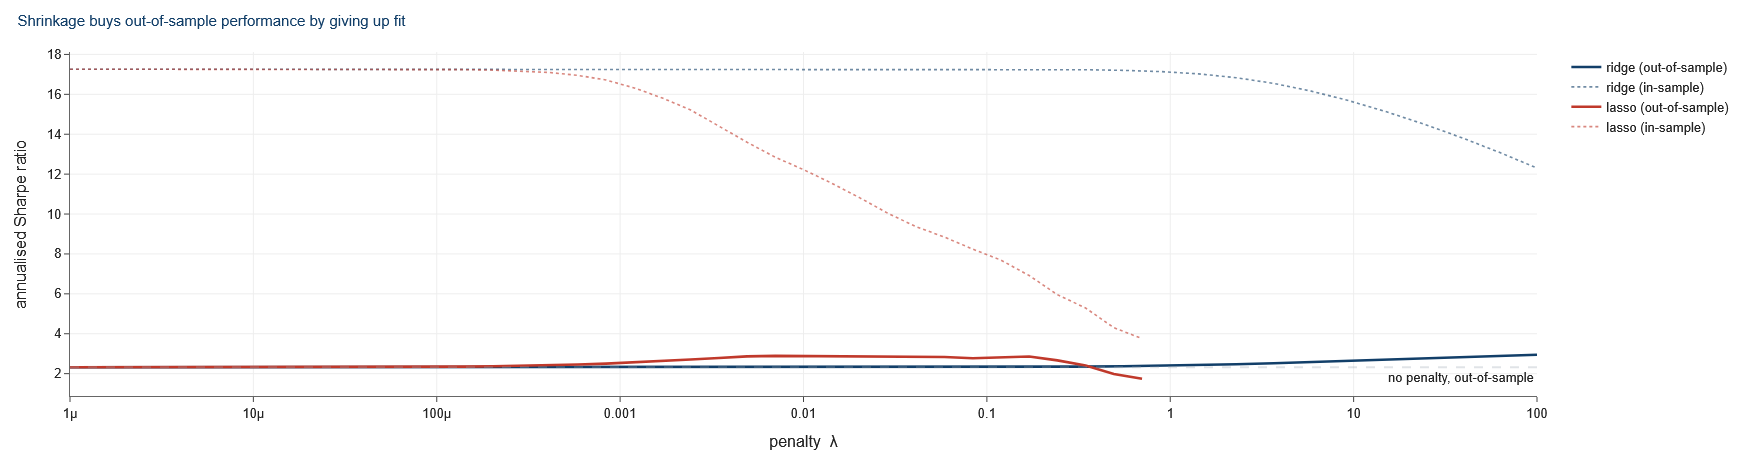

In [15]:
fig = go.Figure()
for (name, df), colour in zip([("ridge", sweeps["ridge"]),
                               ("lasso", sweeps["lasso"])], [NAVY, RED]):
    fig.add_trace(go.Scatter(x=df.param, y=df.oos_sharpe, mode="lines",
                             line=dict(color=colour, width=2.6),
                             name=f"{name} (out-of-sample)"))
    fig.add_trace(go.Scatter(x=df.param, y=df.is_sharpe, mode="lines",
                             line=dict(color=colour, width=1.6, dash="dot"),
                             name=f"{name} (in-sample)", opacity=0.6))
fig.add_hline(y=portfolio_sharpe(R_te, w_ols),
              line=dict(color=GREY, width=2, dash="dash"),
              annotation_text="no penalty, out-of-sample",
              annotation_position="bottom right")
fig.update_xaxes(type="log", title="penalty  λ")
fig.update_yaxes(title="annualised Sharpe ratio")
airm_layout(fig, "Shrinkage buys out-of-sample performance by giving up fit")

The dotted lines fall monotonically as the penalty tightens — in-sample fit can only
get worse. The solid lines **rise, peak and then fall**. That gap between the two is
the entire value of regularisation, and it is why in-sample Sharpe ratios are
worthless as a model selection criterion.

---
## 5. Sparse in *what* space?

Ridge, lasso and PC-ridge all shrink. They disagree about **which coordinates**
should be shrunk hardest, and that disagreement is economic rather than technical.

- **Lasso** says a handful of characteristics matter and the rest are exactly
  irrelevant.
- **Ridge** says many matter a little.
- **PC-ridge** says pricing information lives in the few directions in which returns
  actually vary, and the low-variance directions should be crushed.

### First, look at where the signals actually sit

Before testing whether pricing information concentrates in the leading principal
components, it helps to see the space. Below, every signal is placed by its loadings
on the first three components of the correlation matrix — signals close together
co-move; signals near the origin are largely independent of the common structure.

**Rotate it. Hover any point** for the signal's name, description and Sharpe ratio.

Variance explained: PC1 22.4%, PC2 13.9%, PC3 9.3%  (together 45.7%)
Components needed for 90% of variance: 54 of 158


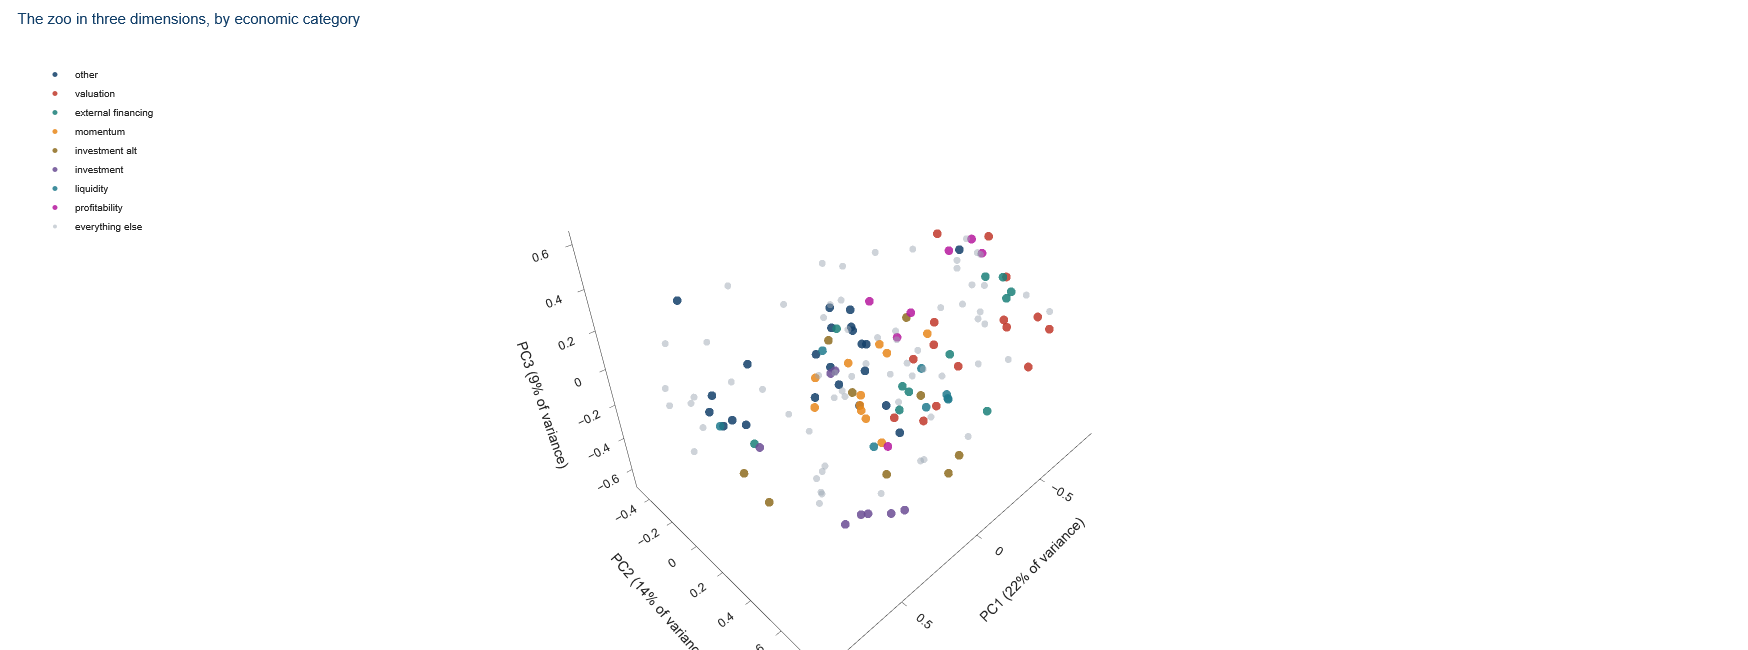

In [16]:
loadings, variance_share = signal_loadings(zoo, n_components=3,
                                           stats=signal_stats(zoo),
                                           doc=describe_signals(zoo.columns))

print(f"Variance explained: PC1 {variance_share[0]:.1%}, "
      f"PC2 {variance_share[1]:.1%}, PC3 {variance_share[2]:.1%}"
      f"  (together {variance_share[:3].sum():.1%})")
print(f"Components needed for 90% of variance: "
      f"{int(np.searchsorted(np.cumsum(variance_share), 0.90) + 1)} "
      f"of {zoo.shape[1]}")

plot_signal_biplot(loadings, variance_share, colour_by="Category",
                   title="The zoo in three dimensions, by economic category")

Three components carry under half the variance, and it takes a large fraction of the
158 to reach 90%. **This zoo has weak common structure** — consistent with the near-zero
average pairwise correlation from Part 1.

Notice too how little the economic categories cluster. Signals filed under the same
theme often sit far apart, and signals from unrelated themes sit together. The labels
describe where an idea *came from*, not how the portfolio *behaves*.

Now the question that matters for the stochastic discount factor: are the
**profitable** signals concentrated anywhere in particular?

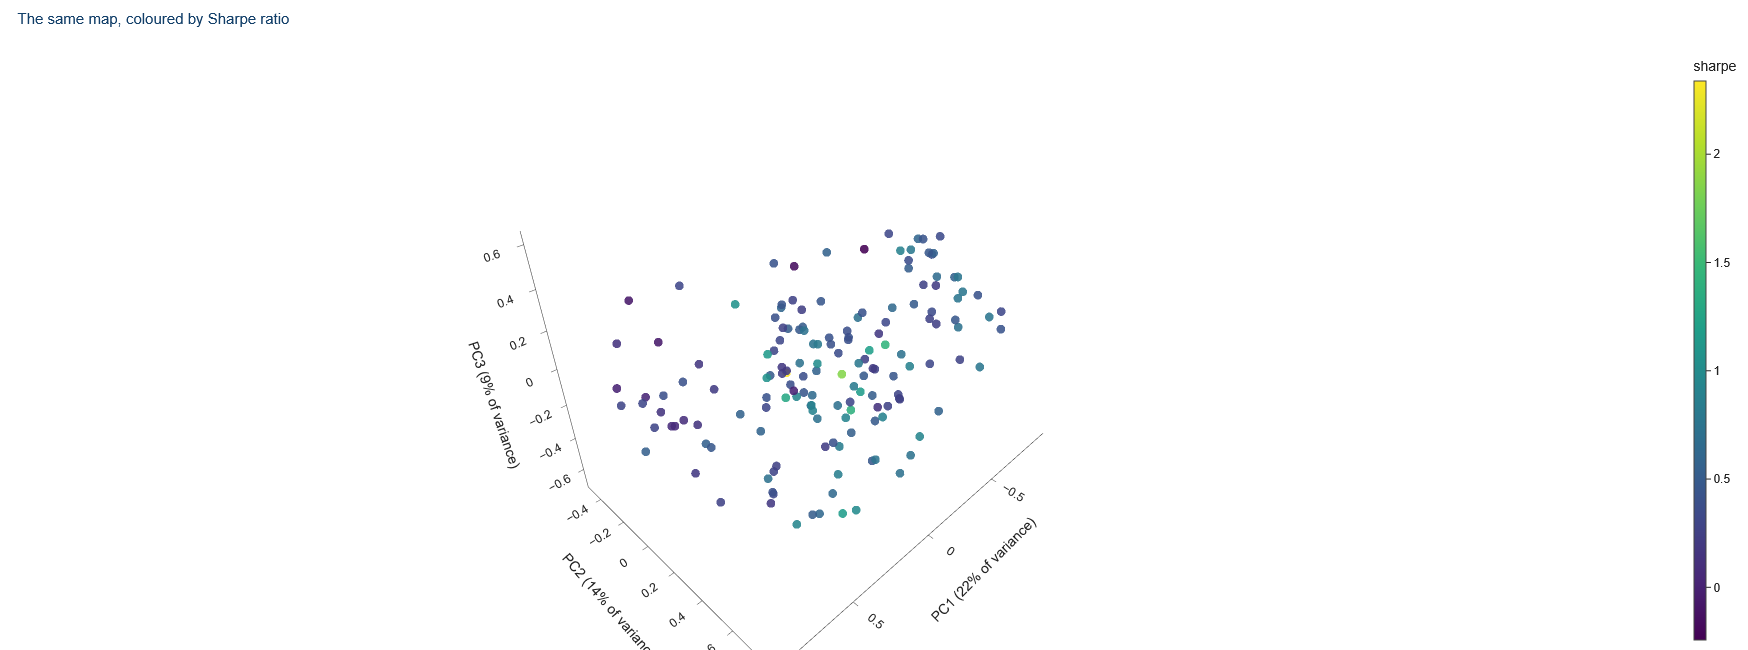

In [17]:
plot_signal_biplot(loadings, variance_share, colour_by="sharpe",
                   title="The same map, coloured by Sharpe ratio")

In [22]:
dist = np.sqrt((loadings[["PC1", "PC2", "PC3"]] ** 2).sum(axis=1))
ok = loadings.sharpe.notna()

print("Does profitability line up with the dominant variance directions?\n")
print(f"   corr(|Sharpe|, |PC1 loading|)        "
      f"{np.corrcoef(loadings.sharpe[ok].abs(), loadings.PC1[ok].abs())[0,1]:+.3f}")
print(f"   corr(|Sharpe|, distance from origin) "
      f"{np.corrcoef(loadings.sharpe[ok].abs(), dist[ok])[0,1]:+.3f}")

Does profitability line up with the dominant variance directions?

   corr(|Sharpe|, |PC1 loading|)        -0.264
   corr(|Sharpe|, distance from origin) -0.120


Both correlations are **negative**. Signals that load heavily on the leading principal
components — the directions in which the zoo actually varies — tend to earn *less*,
not more.

That is the answer to the question this section asks, arrived at before we estimate
anything. If expected returns were concentrated in the high-variance directions, a
stochastic discount factor built from a handful of principal components would work
well. Here they are, if anything, mildly *anti*-aligned.

Keep that picture in mind for the sweep below.

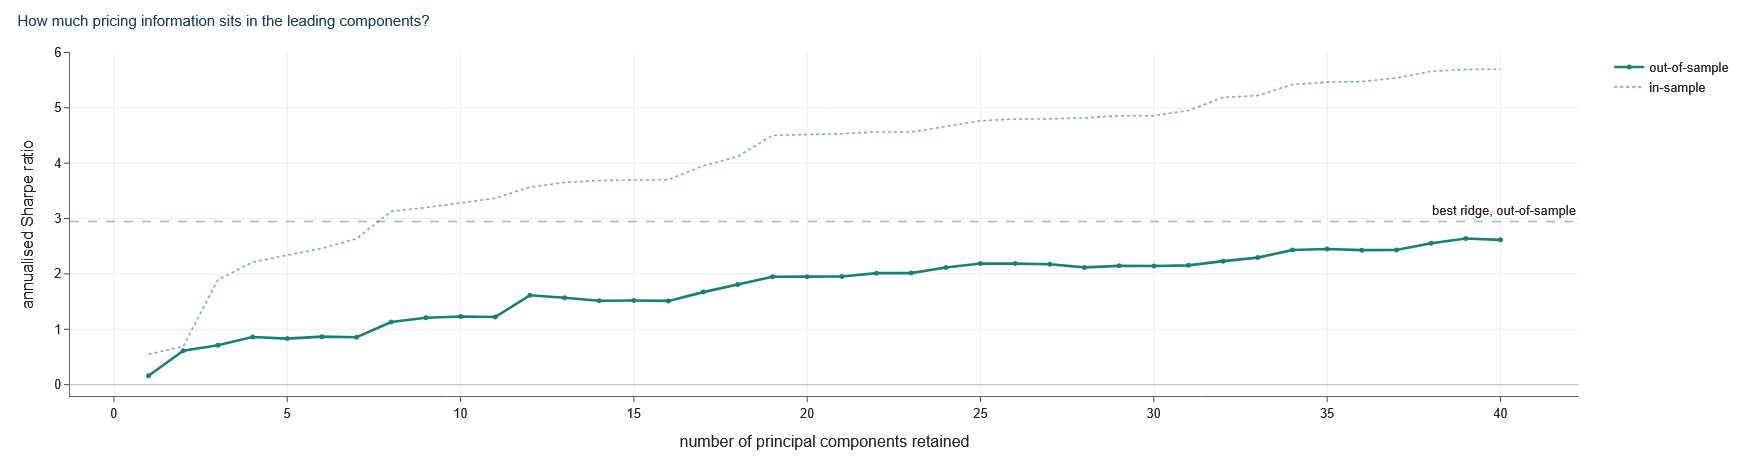

In [23]:
pc = sweeps["pc"]
fig = go.Figure()
fig.add_trace(go.Scatter(x=pc.param, y=pc.oos_sharpe, mode="lines+markers",
                         line=dict(color=TEAL, width=2.6),
                         marker=dict(size=5), name="out-of-sample"))
fig.add_trace(go.Scatter(x=pc.param, y=pc.is_sharpe, mode="lines",
                         line=dict(color=TEAL, width=1.6, dash="dot"),
                         name="in-sample", opacity=0.6))
best_ridge = sweeps["ridge"].oos_sharpe.max()
fig.add_hline(y=best_ridge, line=dict(color=NAVY, width=2, dash="dash"),
              annotation_text="best ridge, out-of-sample",
              annotation_position="top right")
fig.update_xaxes(title="number of principal components retained")
fig.update_yaxes(title="annualised Sharpe ratio")
airm_layout(fig, "How much pricing information sits in the leading components?")

In [24]:
# How much return VARIANCE do the leading components explain?
evals = np.linalg.eigvalsh(np.cov(R_tr, rowvar=False))[::-1]
share = np.cumsum(evals) / evals.sum()
best_ridge = sweeps["ridge"].oos_sharpe.max()
for k in [1, 3, 5, 10, 20]:
    if k <= len(share):
        print(f"   first {k:2d} PCs explain {share[k-1]:5.1%} of return variance"
              f"   |   SDF using them: OOS Sharpe "
              f"{pc.loc[pc.param == k, 'oos_sharpe'].iloc[0]:5.2f}")

   first  1 PCs explain 20.3% of return variance   |   SDF using them: OOS Sharpe  0.16
   first  3 PCs explain 45.9% of return variance   |   SDF using them: OOS Sharpe  0.71
   first  5 PCs explain 53.5% of return variance   |   SDF using them: OOS Sharpe  0.83
   first 10 PCs explain 63.9% of return variance   |   SDF using them: OOS Sharpe  1.23
   first 20 PCs explain 74.8% of return variance   |   SDF using them: OOS Sharpe  1.95


In [25]:
best_pc = pc.loc[pc.oos_sharpe.idxmax()]
pc_at5 = pc.loc[pc.param == 5, "oos_sharpe"]

print(f"Best PC-sparse SDF: {int(best_pc.param)} components "
      f"→ OOS Sharpe {best_pc.oos_sharpe:.2f}")
if len(pc_at5):
    print(f"Only 5 components ({share[4]:.0%} of variance) "
          f"→ OOS Sharpe {pc_at5.iloc[0]:.2f}")
print(f"Best ridge (all signals)      → OOS Sharpe {best_ridge:.2f}")

if best_pc.oos_sharpe >= best_ridge - 0.05 and best_pc.param <= 15:
    print("\n→ Pricing information IS concentrated in a few high-variance")
    print("  directions. This is the Kozak-Nagel-Santosh geometry.")
else:
    print(f"\n→ Pricing information is NOT concentrated in a few components:")
    print(f"  it takes {int(best_pc.param)} of them to get close to ridge, and even")
    print("  then ridge is ahead. The SDF is dense in THIS set of test assets.")

Best PC-sparse SDF: 39 components → OOS Sharpe 2.64
Only 5 components (54% of variance) → OOS Sharpe 0.83
Best ridge (all signals)      → OOS Sharpe 2.95

→ Pricing information is NOT concentrated in a few components:
  it takes 39 of them to get close to ridge, and even
  then ridge is ahead. The SDF is dense in THIS set of test assets.


### What the answer depends on

Whichever way that came out, the important lesson is that **the question is empirical
and the answer depends on the test assets.**

Kozak, Nagel and Santosh report that expected returns align with the leading principal
components, so a PC-sparse stochastic discount factor performs well. Their test assets
are characteristic-managed portfolios of individual stocks, including interactions
between characteristics.

Ours are different objects: 158 published long–short anomaly portfolios. Recall the
statistic from Part 1 — these are close to mutually uncorrelated, with a mean pairwise
correlation near zero. **A set of near-uncorrelated assets has almost no factor
structure to concentrate in**, so no small number of principal components can carry
much of anything. The geometry that makes PC-shrinkage attractive is largely absent
here by construction of the test assets, not by any fact about markets.

That is not a failed replication. It is the more useful lesson:

> "Is the SDF sparse?" has no answer until you say **sparse in what coordinates, and
> across which assets.** Change the test assets and the answer changes.

And note what we did *not* do. We could have tuned the simulated data-generating
process until it reproduced the published result. That would have demonstrated
nothing beyond an ability to reverse-engineer an answer we already knew.

---
## Exercises

### Core

**C1.** Re-run Part 1 with the publication filter switched on
(`make_synthetic_zoo(RNG(7), publication_t=2.0)`). How do precision and recall at
$|t| > 1.96$ change, and why does the direction of the change make sense?

**C2.** In Part 3 we picked the top $k$ signals by in-sample Sharpe. Repeat with
selection by $t$-statistic instead. Does it matter? Should it?

**C3.** The Part 4 sweep standardises each signal to unit volatility before
penalising. Remove that step and rerun. Explain what the penalty is now doing, and
why the resulting SDF is not one you would want.

**C4.** Split the sample into three parts rather than two: choose the penalty on the
middle third and evaluate on the last. How much worse is honest tuning than the
peak of the out-of-sample curve we reported — and which of those two numbers would
you put in a report?

### Stretch

**S1.** Our simulated zoo assumes every signal's premium is constant through time.
Add a regime shift halfway through in which a third of the premia disappear. Which
of the four SDF estimators degrades most gracefully?

**S2.** Implement the elastic net SDF and sweep both $\lambda$ and $\rho$. Does any
mix beat pure ridge out of sample? Relate your answer to Lecture 8a, Part 5.

**S3.** Bonferroni assumes independent tests, and factor returns are anything but.
Estimate the *effective* number of independent tests in the zoo — one route is the
eigenvalue spectrum of the correlation matrix — and derive the hurdle that implies.
Compare it with Harvey, Liu and Zhu's $|t| > 3$.

**S4.** Everything here is gross of costs. Anomaly portfolios differ enormously in
turnover. Assume a cost proportional to turnover, apply it, and rerun Part 3. Which
of the top-ranked signals survive? This is a preview of Section 6 of the lecture.

**S5.** If the real download works for you, run the whole notebook on it and compare
Part 5 against the simulated result. Does the PC-sparse SDF perform well on real
data? Write a paragraph on what that tells you about the cross-section that no
simulation could have told you.

---

### Where this goes next

**Lecture 8c** turns from building portfolios to **testing** models: time-series
alphas, the GRS statistic, and Fama–MacBeth cross-sectional regressions with the
Shanken correction, applied to Ken French's standard test assets — and then to the
shrinkage SDF you have just estimated.